# Time series forecasting

This notebook demonstrates how to perform time series forecasting using different type of models including Convolutional and Recurrent Neural Networks (CNNs and RNNs).

This notebook follows the [TensorFlow Time series forecasting tutorial](https://www.tensorflow.org/tutorials/structured_data/time_series#next_steps) that covers the following topics:


- Forecast for a single time step:
    - A single feature.
    - All features.
- Forecast multiple steps:
    - Single-shot: Make the predictions all at once.
    - Autoregressive: Make one prediction at a time and feed the output back to the model.


## Required imports

In [1]:
%load_ext autoreload
%autoreload 2

In [93]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from forecasting import (
    WindowGenerator,
    Baseline,
    Linear,
    MultiLayerDense,
    MultiStepMultiLayerDense,
    ConvNet,
    RecurrentLSTM,
    compile_and_fit,
    ResidualWrapper,
    MultiStepLastBaseline,
    RepeatBaseline,
    MultiStepLastLinear,
    MultiStepLastMultiLayerDense,
    MultiStepConvNet,
    MultiStepLSTM,
    FeedBack,
)

print("TensorFlow version:", tf.__version__)

sns.set_theme()

TensorFlow version: 2.10.1


## Dataset

We will use the [weather time series dataset](https://www.bgc-jena.mpg.de/wetter/) recorded by the [Max Planck Institute](https://www.bgc-jena.mpg.de/) for Biogeochemistry as in the TensorFlow Time series forecasting tutorial.

This dataset contains 14 different features such as air temperature, atmospheric pressure, and humidity. These were collected every 10 minutes, beginning in 2003. For efficiency, we will use only the data collected between 2009 and 2016. This section of the dataset was prepared by François Chollet for his book [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python)

In [3]:
zip_path = tf.keras.utils.get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=True,
)

csv_path, _ = os.path.splitext(zip_path)

We will just deal with hourly predictions, so start by sub-sampling the data from 10-minute intervals to one-hour intervals:

In [4]:
df = pd.read_csv(csv_path)
# Slice [start:stop:step], starting from index 5 take every 6th record.
df = df[5::6]

# Get date time column and pop it from the dataframe
date_time = pd.to_datetime(df.pop("Date Time"), format="%d.%m.%Y %H:%M:%S")

print("Data shape:", df.shape)
display(df.head())

Data shape: (70091, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


### Data inspection

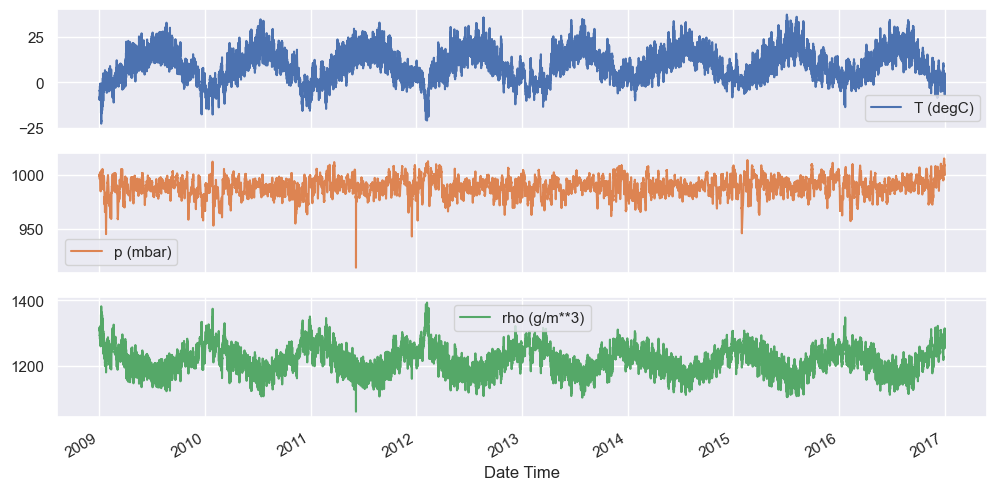

In [5]:
# Plot some variables
plot_cols = ["T (degC)", "p (mbar)", "rho (g/m**3)"]
plot_features = df[plot_cols]
plot_features.index = date_time
plot_features.plot(subplots=True, figsize=(12, 6))
plt.show()

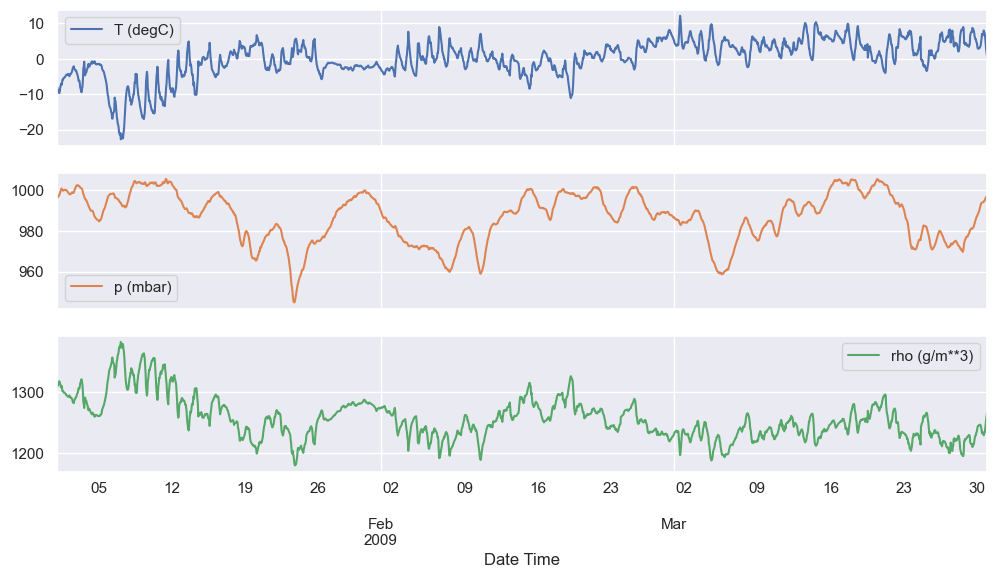

In [6]:
n_days = 89
plot_features = df[plot_cols][: 24 * n_days]
plot_features.index = date_time[: 24 * n_days]
plot_features.plot(subplots=True, figsize=(12, 6))
plt.show()

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


### Wind velocity transformation

In [8]:
# Replace outlier values by 0
wv = df["wv (m/s)"]
bad_wv = wv == -9999.0
wv[bad_wv] = 0.0

max_wv = df["max. wv (m/s)"]
bad_max_wv = max_wv == -9999.0
max_wv[bad_max_wv] = 0.0

### Feature engineering

#### Wind

The column `wd (deg)` gives the wind direction in units of degrees. Angles do not make good model inputs: 360° and 0° should be close to each other and wrap around smoothly. Direction shouldn't matter if the wind is not blowing.

Right now the distribution of wind data looks as follows:

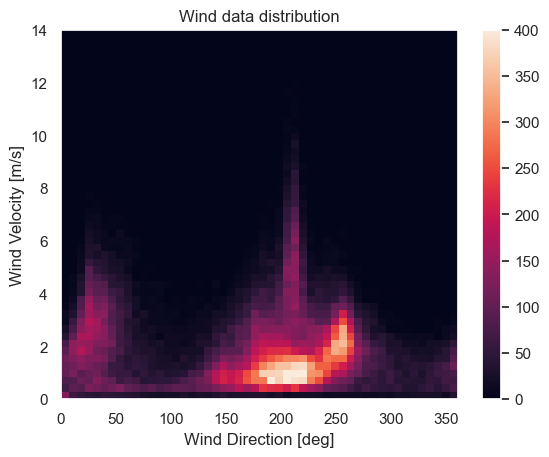

In [9]:
plt.hist2d(df["wd (deg)"], df["wv (m/s)"], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel("Wind Direction [deg]")
plt.ylabel("Wind Velocity [m/s]")
plt.title("Wind data distribution")
plt.show()

We will convert the wind direction and velocity columns to a wind vector:

In [10]:
# Extract wind velocities
wv = df.pop("wv (m/s)")
max_wv = df.pop("max. wv (m/s)")

# Convert to radians.
wd_rad = df.pop("wd (deg)") * np.pi / 180

# Calculate the wind x and y components.
df["Wx"] = wv * np.cos(wd_rad)
df["Wy"] = wv * np.sin(wd_rad)

# Calculate the max wind x and y components.
df["max Wx"] = max_wv * np.cos(wd_rad)
df["max Wy"] = max_wv * np.sin(wd_rad)

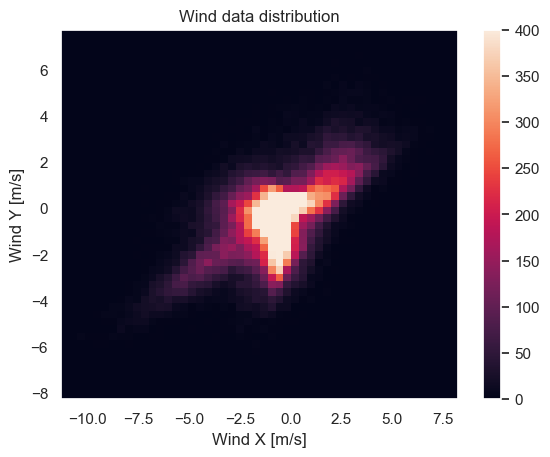

In [11]:
plt.hist2d(df["Wx"], df["Wy"], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel("Wind X [m/s]")
plt.ylabel("Wind Y [m/s]")
plt.title("Wind data distribution")
plt.show()

#### Time

Similarly, the Date Time column is very useful, but not as the current string form. Lest's first convert it to seconds:

In [12]:
timestamp_s = date_time.map(pd.Timestamp.timestamp)

Similar to the wind direction, the time in seconds is not a useful model input. Being weather data, it might have daily and yearly periodicity. We can perform the frequency analysis of the temperature by using the Fast Fourier transform to get periodicity information.

Them we can get usable signals by using sine and cosine transforms to create "Time of day" and "Time of year" signals. This gives the model access to the most important frequency features.

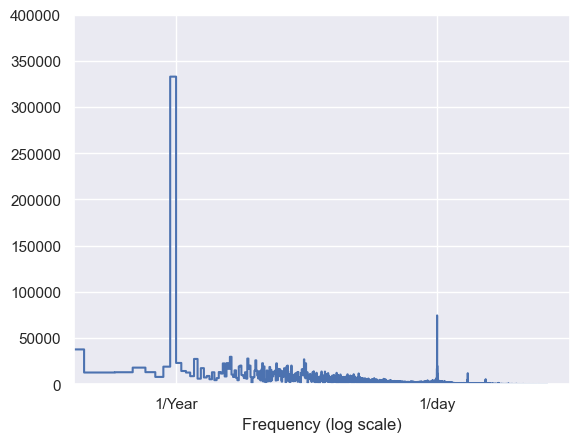

In [13]:
fft = tf.signal.rfft(df["T (degC)"])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df["T (degC)"])
hours_per_year = 24 * 365.2524
years_per_dataset = n_samples_h / (hours_per_year)

f_per_year = f_per_dataset / years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale("log")
plt.ylim(0, 400000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524], labels=["1/Year", "1/day"])
plt.xlabel("Frequency (log scale)")
plt.show()

Then we build the "Time of day" and "Time of year" signals.

In [14]:
day = 24 * 60 * 60
year = (365.2425) * day

df["Day sin"] = np.sin(timestamp_s * (2 * np.pi / day))
df["Day cos"] = np.cos(timestamp_s * (2 * np.pi / day))
df["Year sin"] = np.sin(timestamp_s * (2 * np.pi / year))
df["Year cos"] = np.cos(timestamp_s * (2 * np.pi / year))

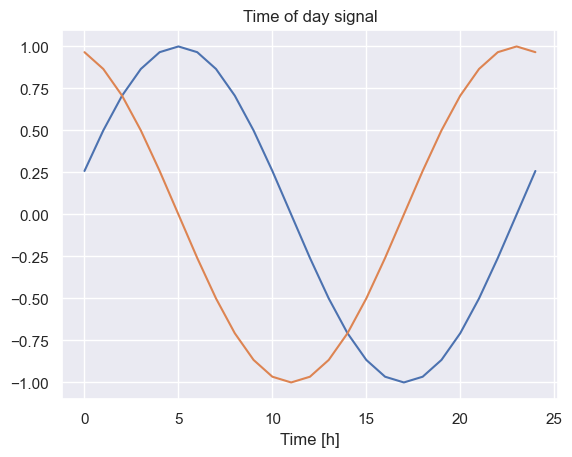

In [15]:
plt.plot(np.array(df["Day sin"])[:25])
plt.plot(np.array(df["Day cos"])[:25])
plt.xlabel("Time [h]")
plt.title("Time of day signal")
plt.show()

## Split the data

We will use a ´(70%, 20%, 10%)´ split for the training, validation, and test sets respectively. Note the data is not being randomly shuffled before splitting. This is for two reasons:

1. It ensures that chopping the data into windows of consecutive samples is still possible.
2. It ensures that the validation/test results are more realistic, being evaluated on the data collected after the model was trained.


In [16]:
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0: int(n * 0.7)]
val_df = df[int(n * 0.7): int(n * 0.9)]
test_df = df[int(n * 0.9):]

num_features = df.shape[1]

## Normalize the data

It is important to scale features before training a neural network. Normalization is a common way of doing this scaling: subtract the mean and divide by the standard deviation of each feature.

The mean and standard deviation should only be computed using the training data so that the models have no access to the values in the validation and test sets.

It's also arguable that the model shouldn't have access to future values in the training set when training, and that this normalization should be done using moving averages. That's not the focus of this tutorial, and the validation and test sets ensure that we get (somewhat) honest metrics. So, in the interest of simplicity this tutorial uses a simple average.

In [17]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

Now, peek at the distribution of the features. Some features do have long tails, but there are no obvious errors like the -9999 wind velocity value.

In [18]:
df_std = (df - train_mean) / train_std
df_std = df_std.melt(var_name="Column", value_name="Normalized")

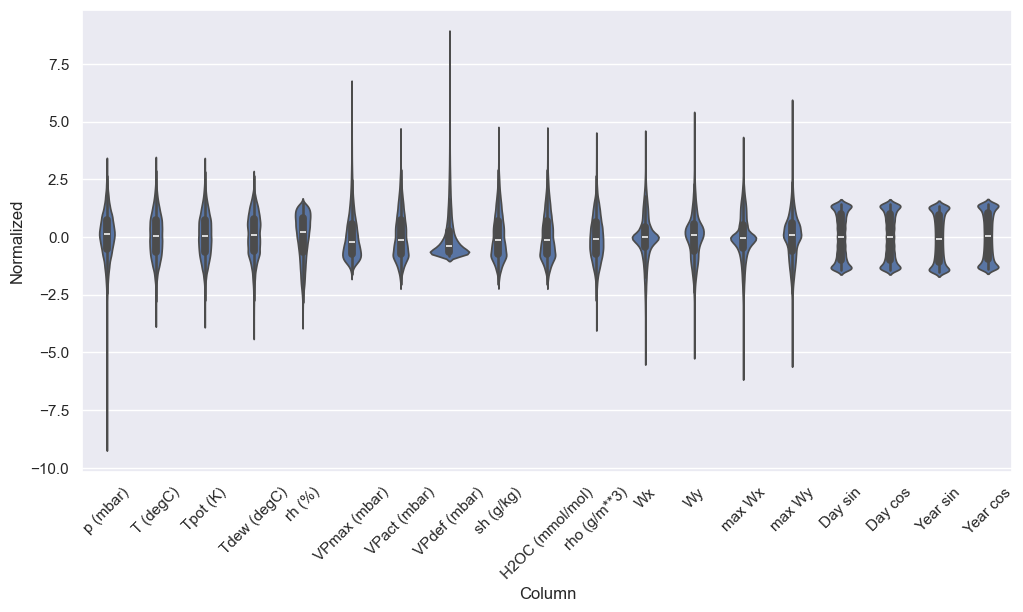

In [19]:
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x="Column", y="Normalized", data=df_std)
ax.set_xticks(df_std["Column"].unique())  # Set the ticks
ax.set_xticklabels(df_std["Column"].unique(), rotation=45)  # Set the tick labels
plt.show()  

## Data windowing

Time series forecasting with deep learning methods relies on creating appropriate time windows (inputs) of consecutive samples from the data and specifying the labels.

The main features of the input windows are:

- The width (number of time steps) of the input and label windows.
- The time offset between them.
- Which features are used as inputs, labels, or both.

Depending on the task and type of model we may want to generate a variety of data windows for Single-output, multi-output,Single-time-step, or multi-time-step predictions.

We define a `WindowGenerator` class. This class can:

1. Handle the indexes and offsets.
2. Split windows of features into (features, labels) pairs.
3. Plot the content of the resulting windows.
4. Efficiently generate batches of these windows from the training, evaluation, and test data, using `tf.data.Datasets`.


In [20]:
w1 = WindowGenerator(
    input_width=24,
    label_width=1,
    shift=24,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=["T (degC)"],
)

# print(w1.label_columns)
# print(w1.label_columns_indices)
# print(w1.column_indices)
# print(w1.label_start)

print("Window 1:")
display(w1)

Window 1:


Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['T (degC)']

In [21]:
w2 = WindowGenerator(
    input_width=6,
    label_width=1,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=["T (degC)"],
)

# print(w2.label_columns)
# print(w2.label_columns_indices)
# print(w2.column_indices)
# print(w2.label_start)

print("Window 2:")
display(w2)

Window 2:


Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['T (degC)']

### Generate example batch

All shapes are: (batch, time, features)
Window shape: (3, 7, 19)
Inputs shape: (3, 6, 19)
Labels shape: (3, 1, 1)


(TensorSpec(shape=(None, 6, 19), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

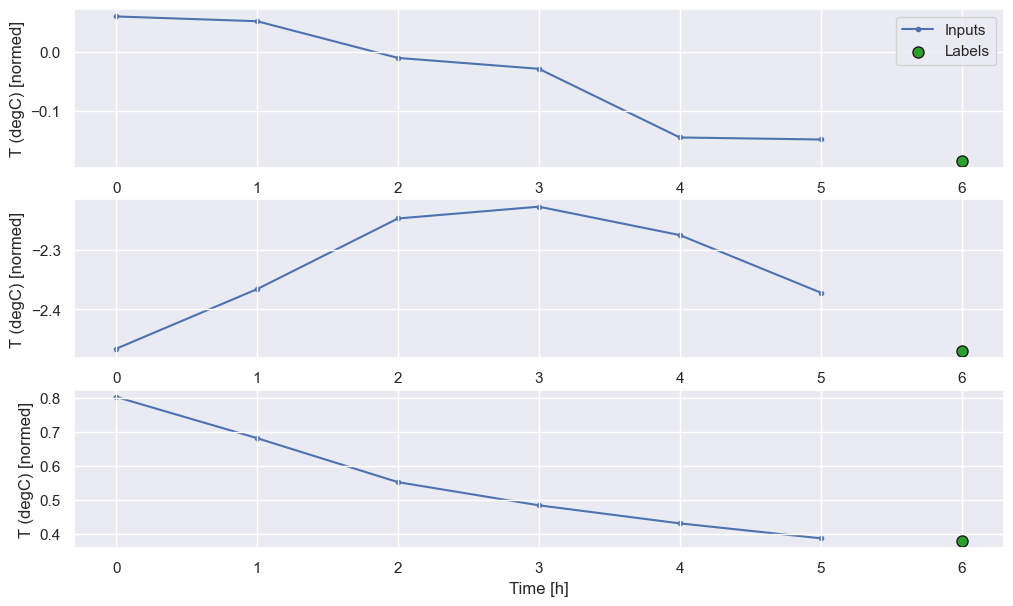

In [22]:
# Generate example batch
# Stack three slices, the length of the total window.
example_window = tf.stack(
    [
        np.array(train_df[: w2.total_window_size]),
        np.array(train_df[100 : 100 + w2.total_window_size]),
        np.array(train_df[200 : 200 + w2.total_window_size]),
    ]
)
# Split into inputs and labels
example_inputs, example_labels = w2.split_window(example_window)

# Stack three slices, the length of the total window.
print("All shapes are: (batch, time, features)")
print(f"Window shape: {example_window.shape}")
print(f"Inputs shape: {example_inputs.shape}")
print(f"Labels shape: {example_labels.shape}")

display(w2.train.element_spec)
w2.plot(plot_col="T (degC)")

# w2.example = example_inputs, example_labels

In [23]:
for example_inputs, example_labels in w2.train.take(1):
    print(f"Inputs shape (batch, time, features): {example_inputs.shape}")
    print(f"Labels shape (batch, time, features): {example_labels.shape}")

Inputs shape (batch, time, features): (32, 6, 19)
Labels shape (batch, time, features): (32, 1, 1)


## Single step models

Before building a trainable model it is important to have a performance baseline as a point for comparison with the later more complicated models.

This first task is to predict temperature one hour into the future, given the current value of all features. The current values include the current temperature.

So, start with a model that just returns the current temperature as the prediction, predicting "No change". This is a reasonable baseline since temperature changes slowly. Of course, this baseline will work less well if we make a prediction further in the future.

In [24]:
single_step_window = WindowGenerator(
    input_width=1,
    label_width=1,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=["T (degC)"],
)

display(single_step_window)

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['T (degC)']

In [25]:
for example_inputs, example_labels in single_step_window.train.take(1):
    print(f"Inputs shape (batch, time, features): {example_inputs.shape}")
    print(f"Labels shape (batch, time, features): {example_labels.shape}")

Inputs shape (batch, time, features): (32, 1, 19)
Labels shape (batch, time, features): (32, 1, 1)


### Baseline

In [26]:
baseline = Baseline(label_index=column_indices["T (degC)"])
baseline.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

val_performance = {}
performance = {}
val_performance['Baseline'] = baseline.evaluate(
    single_step_window.val, return_dict=True)
performance['Baseline'] = baseline.evaluate(
    single_step_window.test, verbose=0, return_dict=True)

439/439 [==============================] - 2s 4ms/step - loss: 0.0128 - mean_absolute_error: 0.0785


That printed some performance metrics, but those don't give us a feeling for how well the model is doing.

The `WindowGenerator` has a plot method, but the plots won't be very interesting with only a single sample.

So, create a wider `WindowGenerator` that generates windows 24 hours of consecutive inputs and labels at a time. The new wide_window variable doesn't change the way the model operates. The model still makes predictions one hour into the future based on a single input time step. Here, the time axis acts like the batch axis: each prediction is made independently with no interaction between time steps:

In [27]:
wide_window = WindowGenerator(
    input_width=24,
    label_width=24,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=["T (degC)"]
)

display(wide_window)
print("Input shape:", wide_window.example[0].shape)
print("Output shape:", baseline(wide_window.example[0]).shape)

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['T (degC)']

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


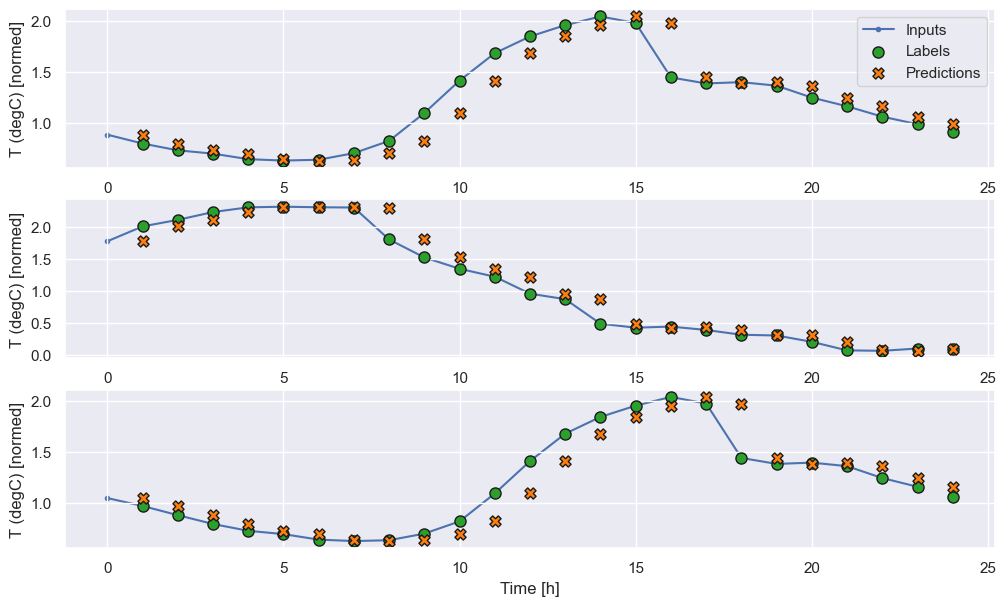

In [28]:
wide_window.plot(plot_col="T (degC)", model=baseline)

### Linear model

The simplest trainable model we can apply to this task is to insert linear transformation between the input and output. In this case the output from a time step only depends on that step:

In [29]:
linear = Linear()

print("Input shape:", single_step_window.example[0].shape)
print("Output shape:", linear(single_step_window.example[0]).shape)

MAX_EPOCHS = 20

history = compile_and_fit(linear, single_step_window, epochs=MAX_EPOCHS)

val_performance['Linear'] = linear.evaluate(
    single_step_window.val, return_dict=True)
performance['Linear'] = linear.evaluate(
    single_step_window.test, verbose=0, return_dict=True)

Input shape: (32, 1, 19)
Output shape: (32, 1, 1)
Epoch 1/20
1534/1534 [==============================] - 13s 8ms/step - loss: 0.2802 - mean_absolute_error: 0.3176 - val_loss: 0.0290 - val_mean_absolute_error: 0.1278
Epoch 2/20
1534/1534 [==============================] - 12s 8ms/step - loss: 0.0171 - mean_absolute_error: 0.0948 - val_loss: 0.0104 - val_mean_absolute_error: 0.0753
Epoch 3/20
1534/1534 [==============================] - 13s 8ms/step - loss: 0.0101 - mean_absolute_error: 0.0737 - val_loss: 0.0097 - val_mean_absolute_error: 0.0735
Epoch 4/20
1534/1534 [==============================] - 13s 8ms/step - loss: 0.0098 - mean_absolute_error: 0.0728 - val_loss: 0.0096 - val_mean_absolute_error: 0.0732
Epoch 5/20
1534/1534 [==============================] - 12s 8ms/step - loss: 0.0097 - mean_absolute_error: 0.0724 - val_loss: 0.0097 - val_mean_absolute_error: 0.0737
Epoch 6/20
1534/1534 [==============================] - 12s 8ms/step - loss: 0.0096 - mean_absolute_error: 0.0720 -

Like the `baseline model`, the linear model can be called on batches of wide windows. Used this way the model makes a set of independent predictions on consecutive time steps. The `time` axis acts like another `batch` axis. There are no interactions between the predictions at each time step.

In [30]:
print("Input shape:", wide_window.example[0].shape)
print("Output shape:", linear(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


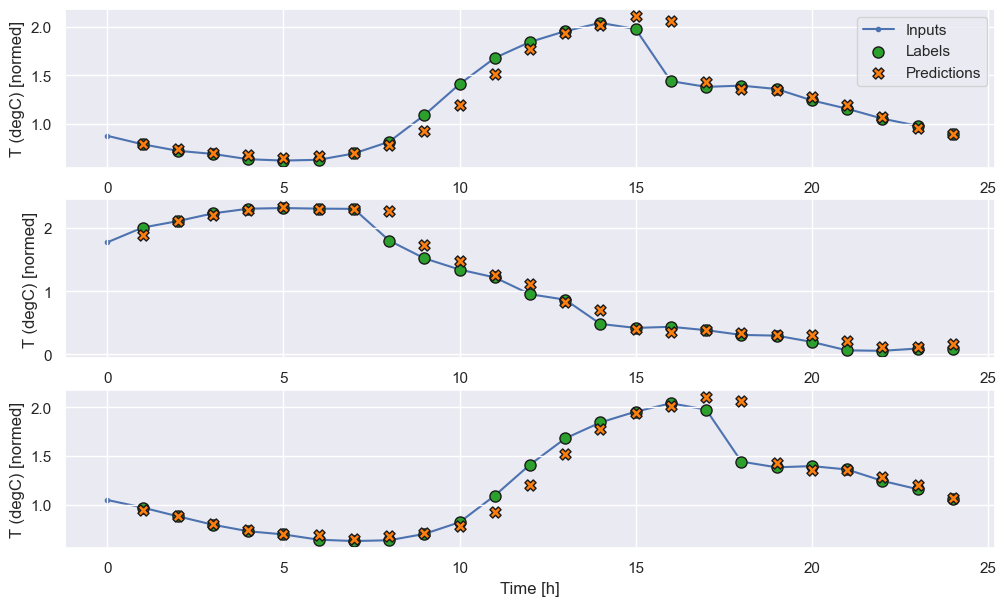

In [31]:
wide_window.plot(plot_col="T (degC)", model=linear)

One advantage to linear models is that they're relatively simple to interpret. You can pull out the layer's weights and visualize the weight assigned to each input:

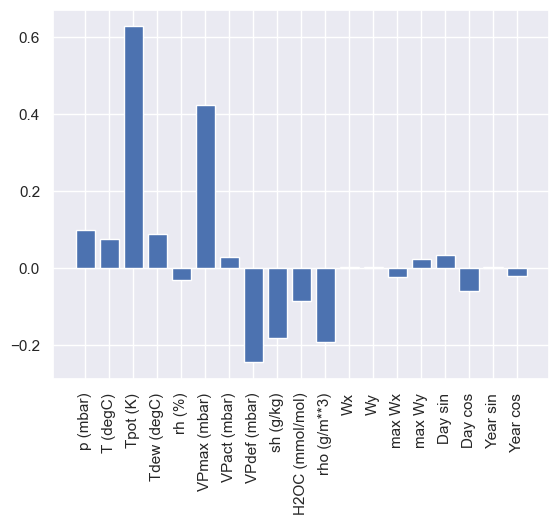

In [32]:
plt.bar(x=range(len(train_df.columns)),
        height=linear.layers[0].kernel[:, 0].numpy())
axis = plt.gca()
axis.set_xticks(range(len(train_df.columns)))
_ = axis.set_xticklabels(train_df.columns, rotation=90)

### Dense

In [33]:
dense = MultiLayerDense()

print("Input shape:", single_step_window.example[0].shape)
print("Output shape:", linear(single_step_window.example[0]).shape)

history = compile_and_fit(dense, single_step_window)

val_performance['Dense'] = dense.evaluate(single_step_window.val, return_dict=True)
performance['Dense'] = dense.evaluate(single_step_window.test, verbose=0, return_dict=True)


Input shape: (32, 1, 19)
Output shape: (32, 1, 1)
Epoch 1/20
1534/1534 [==============================] - 19s 12ms/step - loss: 0.0145 - mean_absolute_error: 0.0791 - val_loss: 0.0076 - val_mean_absolute_error: 0.0625
Epoch 2/20
1534/1534 [==============================] - 18s 12ms/step - loss: 0.0077 - mean_absolute_error: 0.0635 - val_loss: 0.0073 - val_mean_absolute_error: 0.0602
Epoch 3/20
1534/1534 [==============================] - 18s 12ms/step - loss: 0.0074 - mean_absolute_error: 0.0622 - val_loss: 0.0067 - val_mean_absolute_error: 0.0578
Epoch 4/20
1534/1534 [==============================] - 18s 12ms/step - loss: 0.0071 - mean_absolute_error: 0.0606 - val_loss: 0.0067 - val_mean_absolute_error: 0.0575
Epoch 5/20
1534/1534 [==============================] - 18s 12ms/step - loss: 0.0069 - mean_absolute_error: 0.0594 - val_loss: 0.0071 - val_mean_absolute_error: 0.0606
Epoch 6/20
1534/1534 [==============================] - 17s 11ms/step - loss: 0.0069 - mean_absolute_error: 0.

### Multi-step dense

A single-time-step model has no context for the current values of its inputs. It can't see how the input features are changing over time. To address this issue the model needs access to multiple time steps when making predictions:

In [34]:
CONV_WIDTH = 3
conv_window = WindowGenerator(
    input_width=CONV_WIDTH,
    label_width=1,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=["T (degC)"]
)

display(conv_window)

Total window size: 4
Input indices: [0 1 2]
Label indices: [3]
Label column name(s): ['T (degC)']

Text(0.5, 0.98, 'Given 3 hours of inputs, predict 1 hour into the future.')

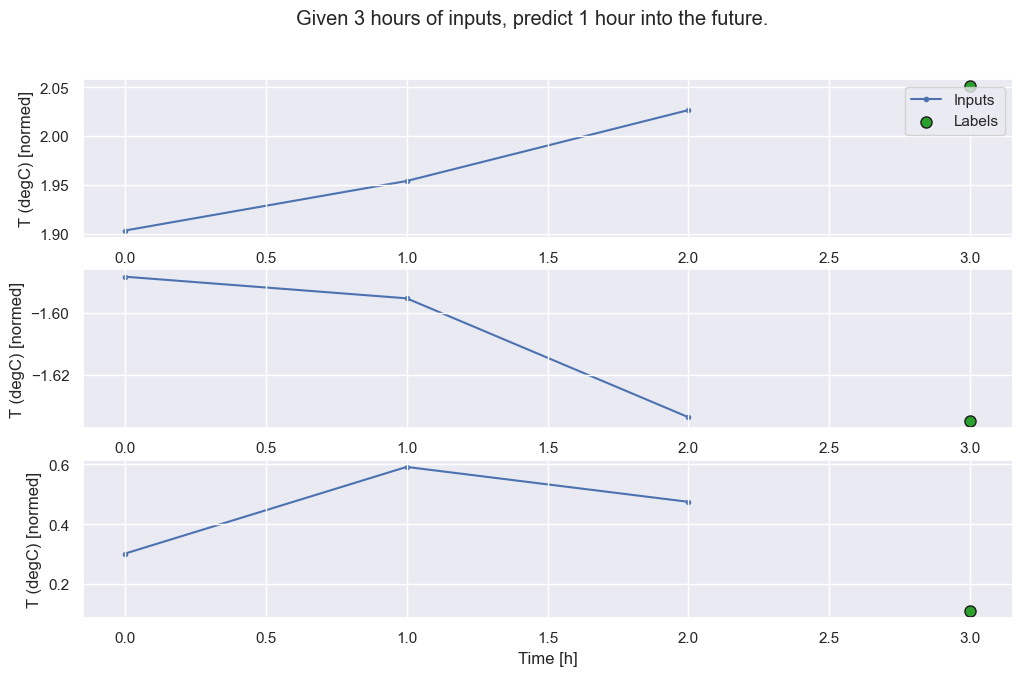

In [35]:
conv_window.plot(plot_col="T (degC)")
plt.suptitle("Given 3 hours of inputs, predict 1 hour into the future.")

### Dense

In [36]:
multi_step_dense = MultiStepMultiLayerDense()
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', multi_step_dense(conv_window.example[0]).shape)

Input shape: (32, 3, 19)
Output shape: (32, 1, 1)


In [37]:
history = compile_and_fit(multi_step_dense, conv_window)
val_performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.val, return_dict=True)
performance['Multi step dense'] = multi_step_dense.evaluate(conv_window.test, verbose=0, return_dict=True)

Epoch 1/20
1534/1534 [==============================] - 13s 8ms/step - loss: 0.0356 - mean_absolute_error: 0.1104 - val_loss: 0.0095 - val_mean_absolute_error: 0.0712
Epoch 2/20
1534/1534 [==============================] - 13s 8ms/step - loss: 0.0088 - mean_absolute_error: 0.0686 - val_loss: 0.0076 - val_mean_absolute_error: 0.0627
Epoch 3/20
1534/1534 [==============================] - 13s 8ms/step - loss: 0.0077 - mean_absolute_error: 0.0634 - val_loss: 0.0071 - val_mean_absolute_error: 0.0602
Epoch 4/20
1534/1534 [==============================] - 13s 8ms/step - loss: 0.0073 - mean_absolute_error: 0.0611 - val_loss: 0.0065 - val_mean_absolute_error: 0.0569
Epoch 5/20
1534/1534 [==============================] - 13s 8ms/step - loss: 0.0071 - mean_absolute_error: 0.0598 - val_loss: 0.0063 - val_mean_absolute_error: 0.0560
Epoch 6/20
1534/1534 [==============================] - 13s 8ms/step - loss: 0.0069 - mean_absolute_error: 0.0592 - val_loss: 0.0064 - val_mean_absolute_error: 0.055

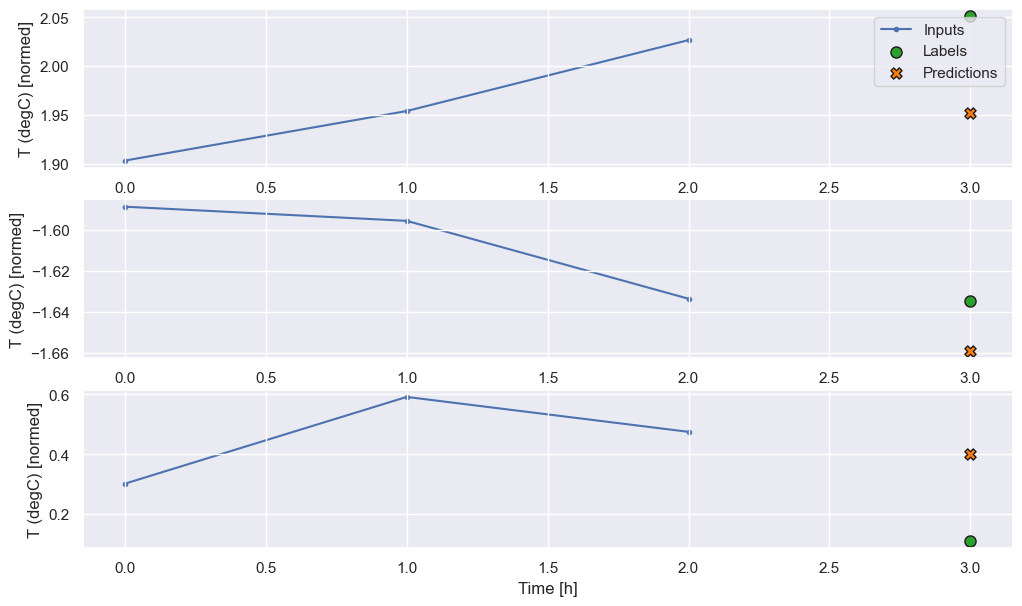

In [38]:
conv_window.plot(plot_col="T (degC)", model=multi_step_dense)

The main down-side of this approach is that the resulting model can only be executed on input windows of exactly this shape. The convolutional models fix this problem.

In [39]:
print('Input shape:', wide_window.example[0].shape)
try:
  print('Output shape:', multi_step_dense(wide_window.example[0]).shape)
except Exception as e:
  print(f'\n{type(e).__name__}:{e}')


Input shape: (32, 24, 19)

ValueError:Exception encountered when calling layer "multi_step_multi_layer_dense" "                 f"(type MultiStepMultiLayerDense).

Input 0 of layer "dense_4" is incompatible with the layer: expected axis -1 of input shape to have value 57, but received input with shape (32, 456)

Call arguments received by layer "multi_step_multi_layer_dense" "                 f"(type MultiStepMultiLayerDense):
  • inputs=tf.Tensor(shape=(32, 24, 19), dtype=float32)


### Convolution neural network

A convolution layer also takes multiple time steps as input to each prediction.

In [40]:
conv_model = ConvNet(kernel_size=CONV_WIDTH)
print("Conv model on `conv_window`")
print('Input shape:', conv_window.example[0].shape)
print('Output shape:', conv_model(conv_window.example[0]).shape)

Conv model on `conv_window`
Input shape: (32, 3, 19)
Output shape: (32, 1, 1)


In [41]:
history = compile_and_fit(conv_model, conv_window)
val_performance['Conv'] = conv_model.evaluate(conv_window.val, return_dict=True)
performance['Conv'] = conv_model.evaluate(conv_window.test, verbose=0, return_dict=True)

Epoch 1/20
1534/1534 [==============================] - 20s 12ms/step - loss: 0.0164 - mean_absolute_error: 0.0884 - val_loss: 0.0087 - val_mean_absolute_error: 0.0682
Epoch 2/20
1534/1534 [==============================] - 17s 11ms/step - loss: 0.0081 - mean_absolute_error: 0.0653 - val_loss: 0.0071 - val_mean_absolute_error: 0.0607
Epoch 3/20
1534/1534 [==============================] - 17s 11ms/step - loss: 0.0074 - mean_absolute_error: 0.0617 - val_loss: 0.0067 - val_mean_absolute_error: 0.0590
Epoch 4/20
1534/1534 [==============================] - 17s 11ms/step - loss: 0.0071 - mean_absolute_error: 0.0601 - val_loss: 0.0074 - val_mean_absolute_error: 0.0632
Epoch 5/20
1534/1534 [==============================] - 17s 11ms/step - loss: 0.0069 - mean_absolute_error: 0.0588 - val_loss: 0.0067 - val_mean_absolute_error: 0.0589
Epoch 6/20
1534/1534 [==============================] - 17s 11ms/step - loss: 0.0068 - mean_absolute_error: 0.0585 - val_loss: 0.0071 - val_mean_absolute_error:

In [42]:
print("Wide window")
print('Input shape:', wide_window.example[0].shape)
print('Labels shape:', wide_window.example[1].shape)
print('Output shape:', conv_model(wide_window.example[0]).shape)

Wide window
Input shape: (32, 24, 19)
Labels shape: (32, 24, 1)
Output shape: (32, 22, 1)


Note that the output is shorter than the input. To make training or plotting work, we need the labels, and prediction to have the same length. So build a `WindowGenerator` to produce wide windows with a few extra input time steps so the label and prediction lengths match:

In [43]:
LABEL_WIDTH = 24
INPUT_WIDTH = LABEL_WIDTH + (CONV_WIDTH - 1)
wide_conv_window = WindowGenerator(
    input_width=INPUT_WIDTH,
    label_width=LABEL_WIDTH,
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=["T (degC)"]
)

display(wide_conv_window)

Total window size: 27
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Label indices: [ 3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26]
Label column name(s): ['T (degC)']

In [44]:
print("Wide conv window")
print('Input shape:', wide_conv_window.example[0].shape)
print('Labels shape:', wide_conv_window.example[1].shape)
print('Output shape:', conv_model(wide_conv_window.example[0]).shape)

Wide conv window
Input shape: (32, 26, 19)
Labels shape: (32, 24, 1)
Output shape: (32, 24, 1)


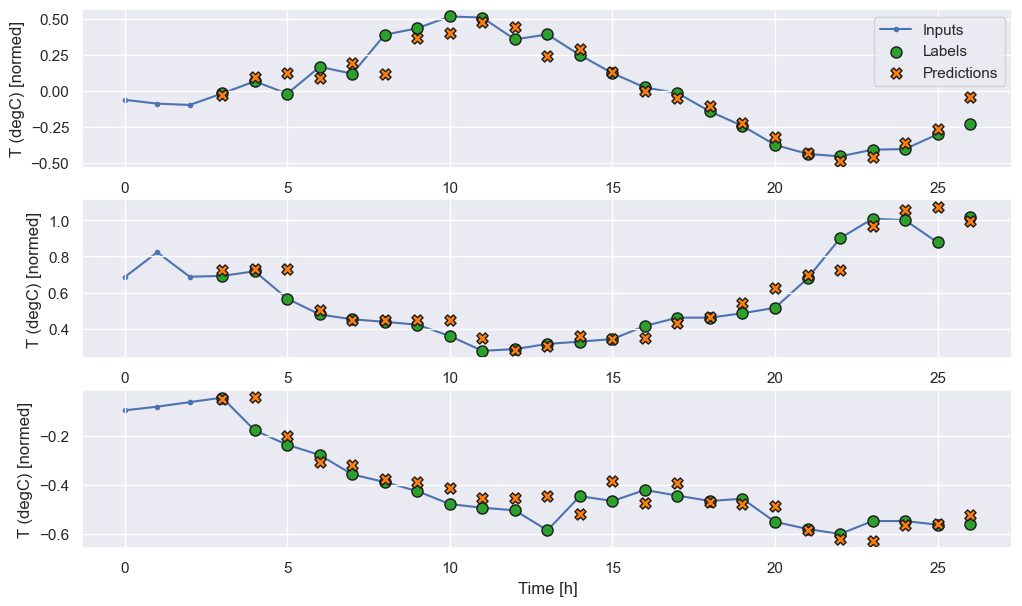

In [45]:
wide_conv_window.plot(plot_col="T (degC)", model=conv_model)

### Recurrent neural networks

In [46]:
lstm_model = RecurrentLSTM()
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

Input shape: (32, 24, 19)
Output shape: (32, 24, 1)


In [47]:
history = compile_and_fit(lstm_model, wide_window)
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val, return_dict=True)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

Epoch 1/20
1533/1533 [==============================] - 30s 19ms/step - loss: 0.0386 - mean_absolute_error: 0.0978 - val_loss: 0.0063 - val_mean_absolute_error: 0.0550
Epoch 2/20
1533/1533 [==============================] - 28s 18ms/step - loss: 0.0062 - mean_absolute_error: 0.0543 - val_loss: 0.0058 - val_mean_absolute_error: 0.0524
Epoch 3/20
1533/1533 [==============================] - 28s 18ms/step - loss: 0.0058 - mean_absolute_error: 0.0522 - val_loss: 0.0056 - val_mean_absolute_error: 0.0516
Epoch 4/20
1533/1533 [==============================] - 27s 18ms/step - loss: 0.0056 - mean_absolute_error: 0.0514 - val_loss: 0.0057 - val_mean_absolute_error: 0.0523
Epoch 5/20
438/438 [==============================] - 5s 10ms/step - loss: 0.0056 - mean_absolute_error: 0.0518


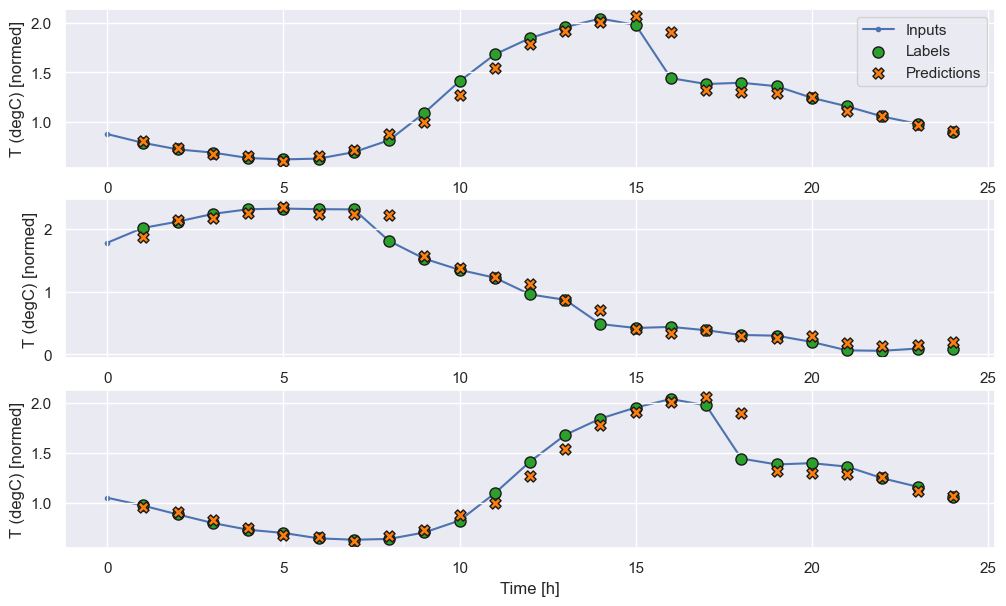

In [48]:
wide_window.plot(plot_col="T (degC)", model=lstm_model)

### Performance

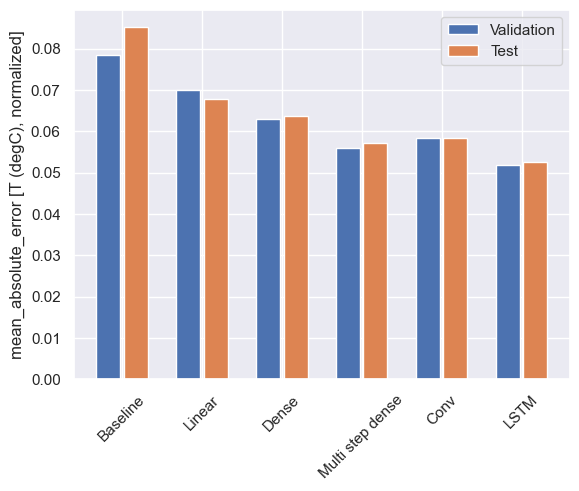

In [49]:
x = np.arange(len(performance))
width = 0.3
metric_name = 'mean_absolute_error'
val_mae = [v[metric_name] for v in val_performance.values()]
test_mae = [v[metric_name] for v in performance.values()]

plt.ylabel('mean_absolute_error [T (degC), normalized]')
plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=performance.keys(),
           rotation=45)
_ = plt.legend()


In [50]:
for name, value in performance.items():
    print(f'{name:12s}: {value[metric_name]:0.4f}')


Baseline    : 0.0852
Linear      : 0.0678
Dense       : 0.0638
Multi step dense: 0.0571
Conv        : 0.0583
LSTM        : 0.0525


### Multi-output models

In [51]:
single_step_window = WindowGenerator(
    # `WindowGenerator` returns all features as labels if you
    # don't set the `label_columns` argument.
    input_width=1, 
    label_width=1, 
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
)

wide_window = WindowGenerator(
    input_width=24, 
    label_width=24, 
    shift=1,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
)

for example_inputs, example_labels in wide_window.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')


Inputs shape (batch, time, features): (32, 24, 19)
Labels shape (batch, time, features): (32, 24, 19)


In [52]:
baseline = Baseline()
baseline.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

val_performance = {}
performance = {}
val_performance["Baseline"] = baseline.evaluate(wide_window.val, return_dict=True)
performance["Baseline"] = baseline.evaluate(wide_window.test, verbose=0, return_dict=True)

438/438 [==============================] - 2s 4ms/step - loss: 0.0886 - mean_absolute_error: 0.1589


In [53]:
dense = MultiLayerDense(output_units=num_features)
history = compile_and_fit(dense, single_step_window)

val_performance["Dense"] = dense.evaluate(single_step_window.val, return_dict=True)
performance["Dense"] = dense.evaluate(single_step_window.test, verbose=0, return_dict=True)

Epoch 1/20
1534/1534 [==============================] - 20s 12ms/step - loss: 0.1060 - mean_absolute_error: 0.1885 - val_loss: 0.0738 - val_mean_absolute_error: 0.1483
Epoch 2/20
1534/1534 [==============================] - 19s 12ms/step - loss: 0.0733 - mean_absolute_error: 0.1457 - val_loss: 0.0722 - val_mean_absolute_error: 0.1426
Epoch 3/20
1534/1534 [==============================] - 19s 12ms/step - loss: 0.0716 - mean_absolute_error: 0.1408 - val_loss: 0.0706 - val_mean_absolute_error: 0.1378
Epoch 4/20
1534/1534 [==============================] - 19s 12ms/step - loss: 0.0706 - mean_absolute_error: 0.1379 - val_loss: 0.0696 - val_mean_absolute_error: 0.1354
Epoch 5/20
1534/1534 [==============================] - 18s 12ms/step - loss: 0.0699 - mean_absolute_error: 0.1358 - val_loss: 0.0688 - val_mean_absolute_error: 0.1343
Epoch 6/20
1534/1534 [==============================] - 18s 12ms/step - loss: 0.0695 - mean_absolute_error: 0.1345 - val_loss: 0.0686 - val_mean_absolute_error:

In [54]:
lstm_model = RecurrentLSTM(output_units=num_features)
history = compile_and_fit(lstm_model, wide_window)

val_performance["LSTM"] = lstm_model.evaluate(wide_window.val, return_dict=True)
performance["LSTM"] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

Epoch 1/20
1533/1533 [==============================] - 30s 18ms/step - loss: 0.1403 - mean_absolute_error: 0.2183 - val_loss: 0.0710 - val_mean_absolute_error: 0.1421
Epoch 2/20
1533/1533 [==============================] - 28s 18ms/step - loss: 0.0674 - mean_absolute_error: 0.1349 - val_loss: 0.0655 - val_mean_absolute_error: 0.1306
Epoch 3/20
1533/1533 [==============================] - 28s 18ms/step - loss: 0.0641 - mean_absolute_error: 0.1277 - val_loss: 0.0639 - val_mean_absolute_error: 0.1264
Epoch 4/20
1533/1533 [==============================] - 28s 18ms/step - loss: 0.0630 - mean_absolute_error: 0.1250 - val_loss: 0.0632 - val_mean_absolute_error: 0.1244
Epoch 5/20
1533/1533 [==============================] - 28s 18ms/step - loss: 0.0624 - mean_absolute_error: 0.1236 - val_loss: 0.0627 - val_mean_absolute_error: 0.1234
Epoch 6/20
1533/1533 [==============================] - 28s 18ms/step - loss: 0.0620 - mean_absolute_error: 0.1228 - val_loss: 0.0629 - val_mean_absolute_error:

### Advanced: Residual connections

In [55]:
residual_lstm = ResidualWrapper(
    model=RecurrentLSTM(output_units=num_features)
)
history = compile_and_fit(residual_lstm, wide_window)

val_performance["Residual LSTM"] = residual_lstm.evaluate(wide_window.val, return_dict=True)
performance["Residual LSTM"] = residual_lstm.evaluate(wide_window.test, verbose=0, return_dict=True)


Epoch 1/20
1533/1533 [==============================] - 30s 18ms/step - loss: 0.0657 - mean_absolute_error: 0.1227 - val_loss: 0.0629 - val_mean_absolute_error: 0.1190
Epoch 2/20
1533/1533 [==============================] - 27s 18ms/step - loss: 0.0619 - mean_absolute_error: 0.1180 - val_loss: 0.0619 - val_mean_absolute_error: 0.1179
Epoch 3/20
1533/1533 [==============================] - 27s 18ms/step - loss: 0.0609 - mean_absolute_error: 0.1171 - val_loss: 0.0617 - val_mean_absolute_error: 0.1177
Epoch 4/20
1533/1533 [==============================] - 27s 18ms/step - loss: 0.0604 - mean_absolute_error: 0.1165 - val_loss: 0.0616 - val_mean_absolute_error: 0.1176
Epoch 5/20
1533/1533 [==============================] - 27s 18ms/step - loss: 0.0599 - mean_absolute_error: 0.1162 - val_loss: 0.0617 - val_mean_absolute_error: 0.1176
Epoch 6/20
438/438 [==============================] - 5s 10ms/step - loss: 0.0619 - mean_absolute_error: 0.1179


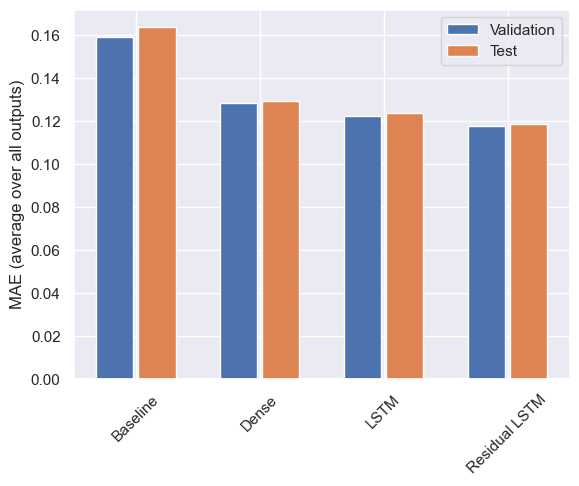

In [56]:
x = np.arange(len(performance))
width = 0.3

metric_name = "mean_absolute_error"
val_mae = [v[metric_name] for v in val_performance.values()]
test_mae = [v[metric_name] for v in performance.values()]

plt.bar(x - 0.17, val_mae, width, label="Validation")
plt.bar(x + 0.17, test_mae, width, label="Test")
plt.xticks(ticks=x, labels=performance.keys(),
           rotation=45)
plt.ylabel("MAE (average over all outputs)")
_ = plt.legend()


In [57]:
for name, value in performance.items():
  print(f'{name:15s}: {value[metric_name]:0.4f}')


Baseline       : 0.1638
Dense          : 0.1296
LSTM           : 0.1239
Residual LSTM  : 0.1188


## Multi-step models

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]
Label column name(s): None

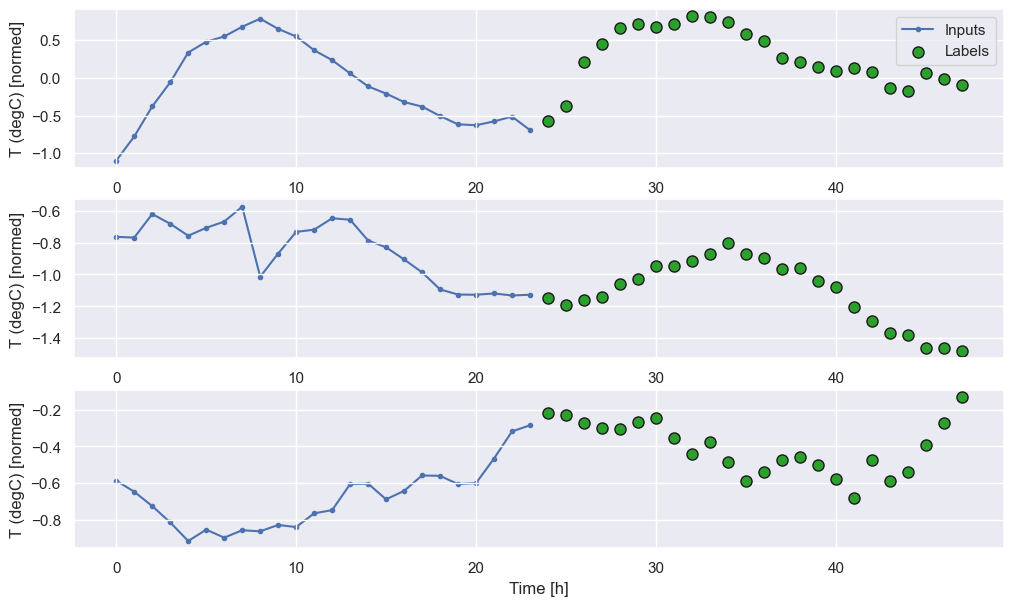

In [58]:
OUT_STEPS = 24
multi_window = WindowGenerator(
    input_width=24,
    label_width=OUT_STEPS,
    shift=OUT_STEPS,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
)

multi_window.plot(plot_col="T (degC)")
display(multi_window)

### Baselines

In [59]:
last_baseline = MultiStepLastBaseline(out_steps=OUT_STEPS)
last_baseline.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

multi_val_performance = {}
multi_performance = {}

multi_val_performance["Last"] = last_baseline.evaluate(multi_window.val, return_dict=True)
multi_performance["Last"] = last_baseline.evaluate(multi_window.test, verbose=0, return_dict=True)

437/437 [==============================] - 2s 4ms/step - loss: 0.6285 - mean_absolute_error: 0.5007


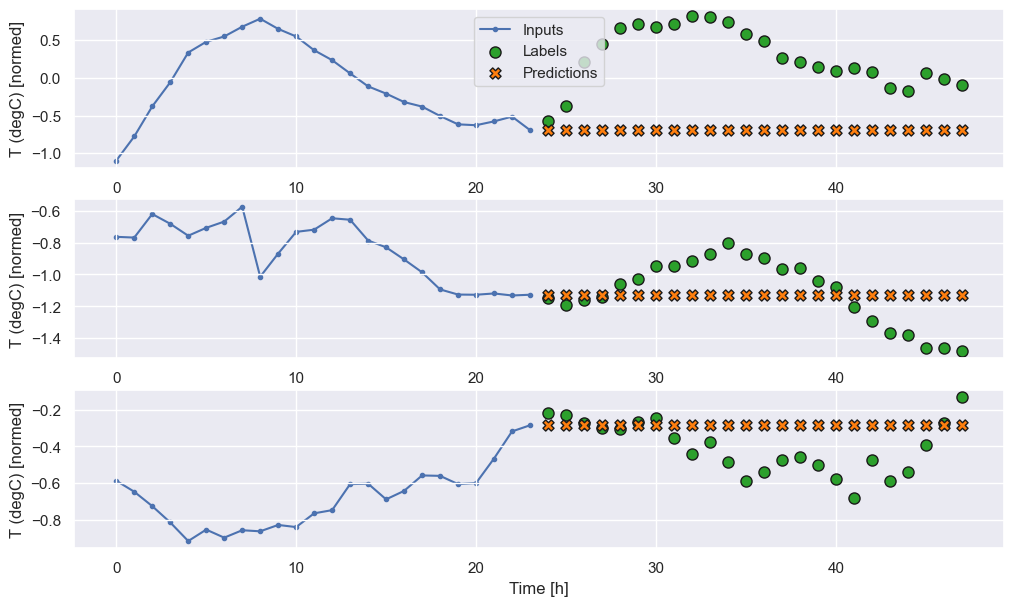

In [60]:
multi_window.plot(model=last_baseline, plot_col="T (degC)")

In [61]:
repeat_baseline = RepeatBaseline()
repeat_baseline.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

multi_val_performance["Repeat"] = repeat_baseline.evaluate(multi_window.val, return_dict=True)
multi_performance["Repeat"] = repeat_baseline.evaluate(multi_window.test, verbose=0, return_dict=True)


437/437 [==============================] - 2s 5ms/step - loss: 0.4270 - mean_absolute_error: 0.3959


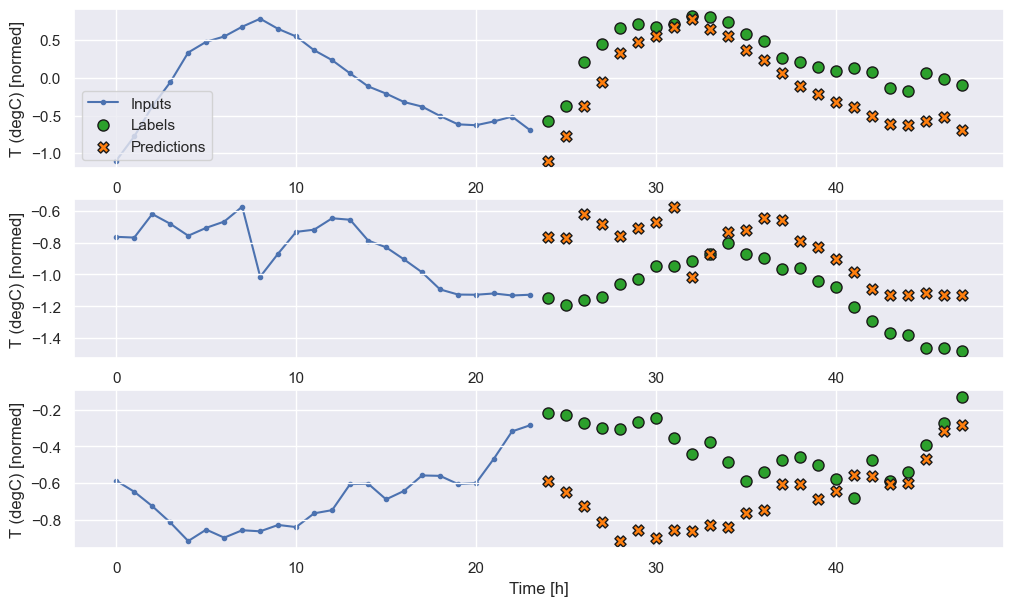

In [62]:
multi_window.plot(model=repeat_baseline, plot_col="T (degC)")


## Single-shot models

### Linear

A simple linear model based on the last input time step does better than either baseline, but is underpowered. The model needs to predict OUTPUT_STEPS time steps, from a single input time step with a linear projection. It can only capture a low-dimensional slice of the behavior, likely based mainly on the time of day and time of year.

In [63]:
multi_linear_model = MultiStepLastLinear(out_steps=OUT_STEPS, output_units=num_features)
history = compile_and_fit(multi_linear_model, multi_window)

multi_val_performance["Linear"] = multi_linear_model.evaluate(multi_window.val, return_dict=True)
multi_performance["Linear"] = multi_linear_model.evaluate(multi_window.test, verbose=0, return_dict=True)

Epoch 1/20
1532/1532 [==============================] - 13s 8ms/step - loss: 0.3285 - mean_absolute_error: 0.3984 - val_loss: 0.2590 - val_mean_absolute_error: 0.3232
Epoch 2/20
1532/1532 [==============================] - 12s 8ms/step - loss: 0.2571 - mean_absolute_error: 0.3128 - val_loss: 0.2558 - val_mean_absolute_error: 0.3055
Epoch 3/20
1532/1532 [==============================] - 12s 8ms/step - loss: 0.2562 - mean_absolute_error: 0.3074 - val_loss: 0.2558 - val_mean_absolute_error: 0.3046
Epoch 4/20
1532/1532 [==============================] - 13s 8ms/step - loss: 0.2562 - mean_absolute_error: 0.3072 - val_loss: 0.2553 - val_mean_absolute_error: 0.3044
Epoch 5/20
1532/1532 [==============================] - 13s 8ms/step - loss: 0.2561 - mean_absolute_error: 0.3072 - val_loss: 0.2554 - val_mean_absolute_error: 0.3046
Epoch 6/20
437/437 [==============================] - 3s 6ms/step - loss: 0.2557 - mean_absolute_error: 0.3045


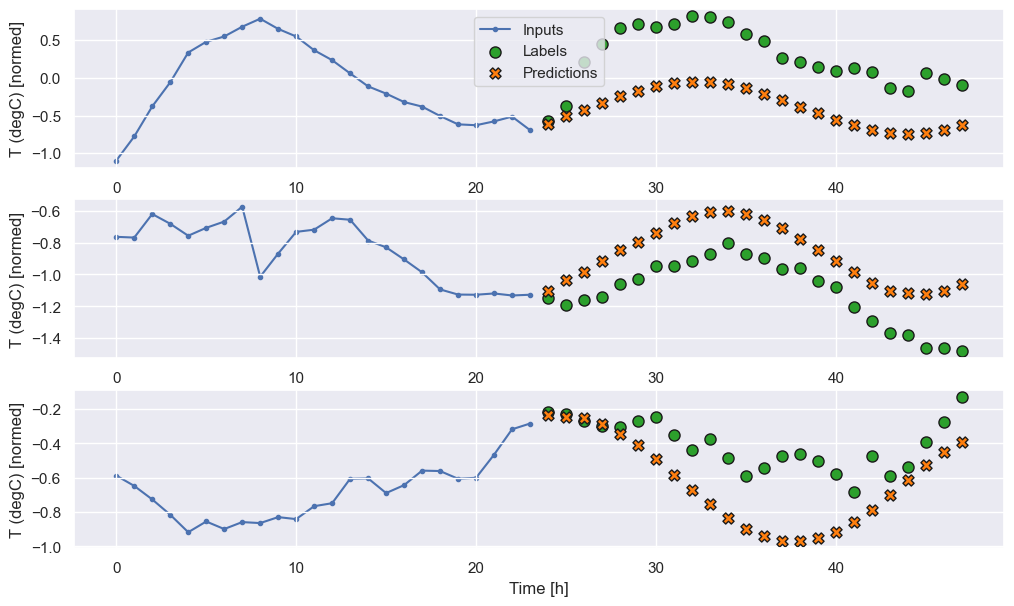

In [64]:
multi_window.plot(model=multi_linear_model, plot_col="T (degC)")

### Dense

In [65]:
multi_dense_model = MultiStepLastMultiLayerDense(out_steps=OUT_STEPS, output_units=num_features)
history = compile_and_fit(multi_dense_model, multi_window)

multi_val_performance["Dense"] = multi_dense_model.evaluate(multi_window.val, return_dict=True)
multi_performance["Dense"] = multi_dense_model.evaluate(multi_window.test, verbose=0, return_dict=True)

Epoch 1/20
1532/1532 [==============================] - 19s 12ms/step - loss: 0.2390 - mean_absolute_error: 0.3008 - val_loss: 0.2247 - val_mean_absolute_error: 0.2862
Epoch 2/20
1532/1532 [==============================] - 18s 12ms/step - loss: 0.2223 - mean_absolute_error: 0.2846 - val_loss: 0.2232 - val_mean_absolute_error: 0.2848
Epoch 3/20
1532/1532 [==============================] - 19s 12ms/step - loss: 0.2192 - mean_absolute_error: 0.2818 - val_loss: 0.2205 - val_mean_absolute_error: 0.2828
Epoch 4/20
1532/1532 [==============================] - 19s 12ms/step - loss: 0.2166 - mean_absolute_error: 0.2798 - val_loss: 0.2192 - val_mean_absolute_error: 0.2808
Epoch 5/20
1532/1532 [==============================] - 19s 12ms/step - loss: 0.2146 - mean_absolute_error: 0.2781 - val_loss: 0.2185 - val_mean_absolute_error: 0.2805
Epoch 6/20
1532/1532 [==============================] - 18s 12ms/step - loss: 0.2129 - mean_absolute_error: 0.2767 - val_loss: 0.2176 - val_mean_absolute_error:

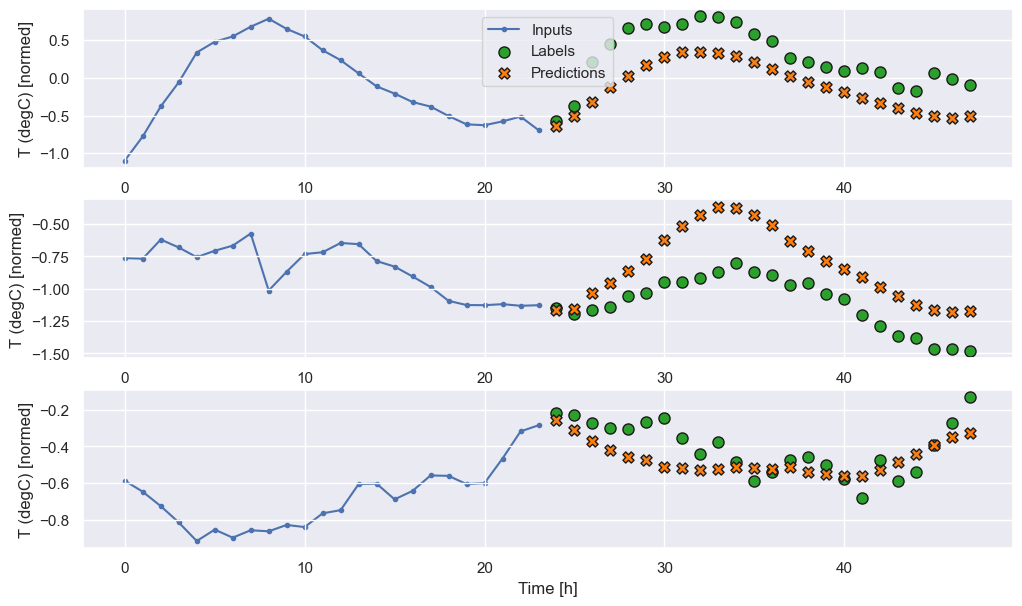

In [66]:
multi_window.plot(model=multi_dense_model, plot_col="T (degC)")

### CNN

In [67]:
multi_conv_model = MultiStepConvNet(kernel_size=CONV_WIDTH, out_steps=OUT_STEPS, output_units=num_features)
history = compile_and_fit(multi_conv_model, multi_window)

multi_val_performance["Conv"] = multi_conv_model.evaluate(multi_window.val, return_dict=True)
multi_performance["Conv"] = multi_conv_model.evaluate(multi_window.test, verbose=0, return_dict=True)

Epoch 1/20
1532/1532 [==============================] - 17s 11ms/step - loss: 0.2381 - mean_absolute_error: 0.3042 - val_loss: 0.2240 - val_mean_absolute_error: 0.2910
Epoch 2/20
1532/1532 [==============================] - 15s 10ms/step - loss: 0.2192 - mean_absolute_error: 0.2858 - val_loss: 0.2226 - val_mean_absolute_error: 0.2892
Epoch 3/20
1532/1532 [==============================] - 16s 10ms/step - loss: 0.2156 - mean_absolute_error: 0.2827 - val_loss: 0.2205 - val_mean_absolute_error: 0.2873
Epoch 4/20
1532/1532 [==============================] - 16s 10ms/step - loss: 0.2128 - mean_absolute_error: 0.2802 - val_loss: 0.2181 - val_mean_absolute_error: 0.2857
Epoch 5/20
1532/1532 [==============================] - 16s 10ms/step - loss: 0.2102 - mean_absolute_error: 0.2779 - val_loss: 0.2168 - val_mean_absolute_error: 0.2834
Epoch 6/20
1532/1532 [==============================] - 16s 10ms/step - loss: 0.2085 - mean_absolute_error: 0.2764 - val_loss: 0.2179 - val_mean_absolute_error:

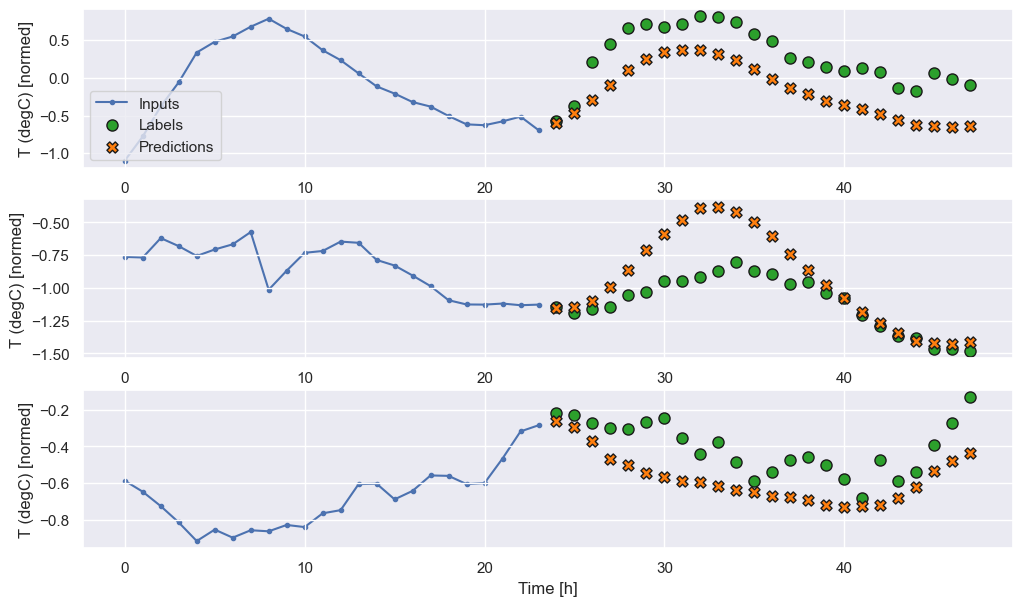

In [68]:
multi_window.plot(model=multi_conv_model, plot_col="T (degC)")

### RNN

In [91]:
multi_lstm_model = MultiStepLSTM(out_steps=OUT_STEPS, output_units=num_features)
history = compile_and_fit(multi_lstm_model, multi_window)

multi_val_performance["LSTM"] = multi_lstm_model.evaluate(multi_window.val, return_dict=True)
multi_performance["LSTM"] = multi_lstm_model.evaluate(multi_window.test, verbose=0, return_dict=True)

Epoch 1/20
1532/1532 [==============================] - 27s 16ms/step - loss: 0.2889 - mean_absolute_error: 0.3603 - val_loss: 0.2312 - val_mean_absolute_error: 0.3067
Epoch 2/20
1532/1532 [==============================] - 24s 16ms/step - loss: 0.2161 - mean_absolute_error: 0.2937 - val_loss: 0.2214 - val_mean_absolute_error: 0.2939
Epoch 3/20
1532/1532 [==============================] - 23s 15ms/step - loss: 0.2079 - mean_absolute_error: 0.2845 - val_loss: 0.2182 - val_mean_absolute_error: 0.2894
Epoch 4/20
1532/1532 [==============================] - 24s 15ms/step - loss: 0.2038 - mean_absolute_error: 0.2802 - val_loss: 0.2155 - val_mean_absolute_error: 0.2863
Epoch 5/20
1532/1532 [==============================] - 24s 15ms/step - loss: 0.2011 - mean_absolute_error: 0.2777 - val_loss: 0.2150 - val_mean_absolute_error: 0.2858
Epoch 6/20
1532/1532 [==============================] - 24s 16ms/step - loss: 0.1991 - mean_absolute_error: 0.2760 - val_loss: 0.2152 - val_mean_absolute_error:

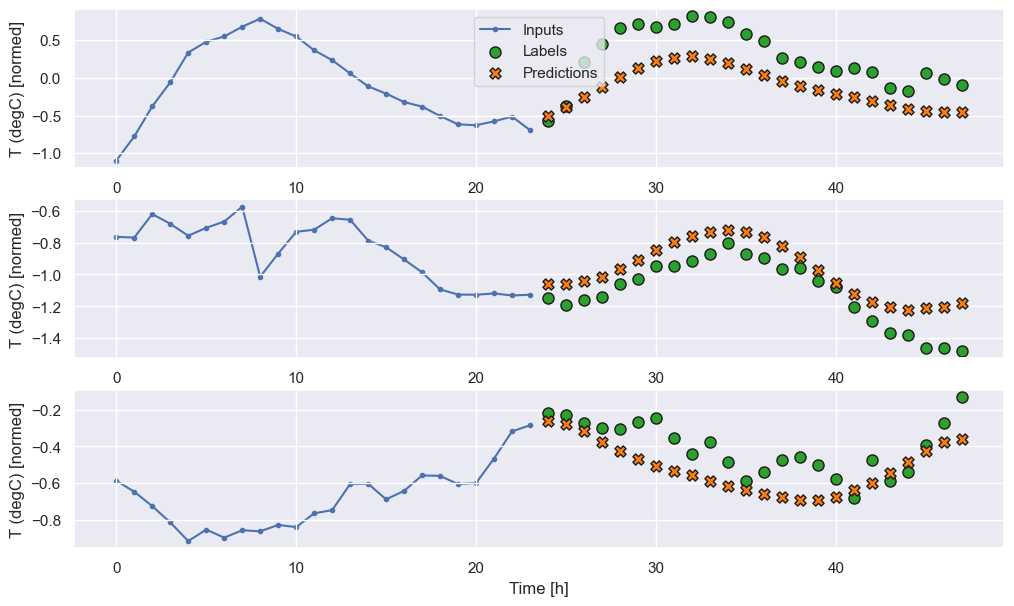

In [92]:
multi_window.plot(model=multi_lstm_model, plot_col="T (degC)")

## Advanced: Autoregressive model

In [94]:
feedback_model = FeedBack(units=32, out_steps=OUT_STEPS, output_units=num_features)
history = compile_and_fit(feedback_model, multi_window)
multi_val_performance["AR LSTM"] = feedback_model.evaluate(multi_window.val, return_dict=True)
multi_performance["AR LSTM"] = feedback_model.evaluate(multi_window.test, verbose=0, return_dict=True)

Epoch 1/20
1532/1532 [==============================] - 369s 237ms/step - loss: 0.3080 - mean_absolute_error: 0.3819 - val_loss: 0.2465 - val_mean_absolute_error: 0.3283
Epoch 2/20
1532/1532 [==============================] - 364s 238ms/step - loss: 0.2325 - mean_absolute_error: 0.3153 - val_loss: 0.2338 - val_mean_absolute_error: 0.3133
Epoch 3/20
1532/1532 [==============================] - 359s 234ms/step - loss: 0.2231 - mean_absolute_error: 0.3042 - val_loss: 0.2299 - val_mean_absolute_error: 0.3068
Epoch 4/20
1532/1532 [==============================] - 360s 235ms/step - loss: 0.2180 - mean_absolute_error: 0.2985 - val_loss: 0.2279 - val_mean_absolute_error: 0.3045
Epoch 5/20
1532/1532 [==============================] - 364s 238ms/step - loss: 0.2143 - mean_absolute_error: 0.2949 - val_loss: 0.2245 - val_mean_absolute_error: 0.3012
Epoch 6/20
1532/1532 [==============================] - 370s 241ms/step - loss: 0.2111 - mean_absolute_error: 0.2923 - val_loss: 0.2247 - val_mean_abs

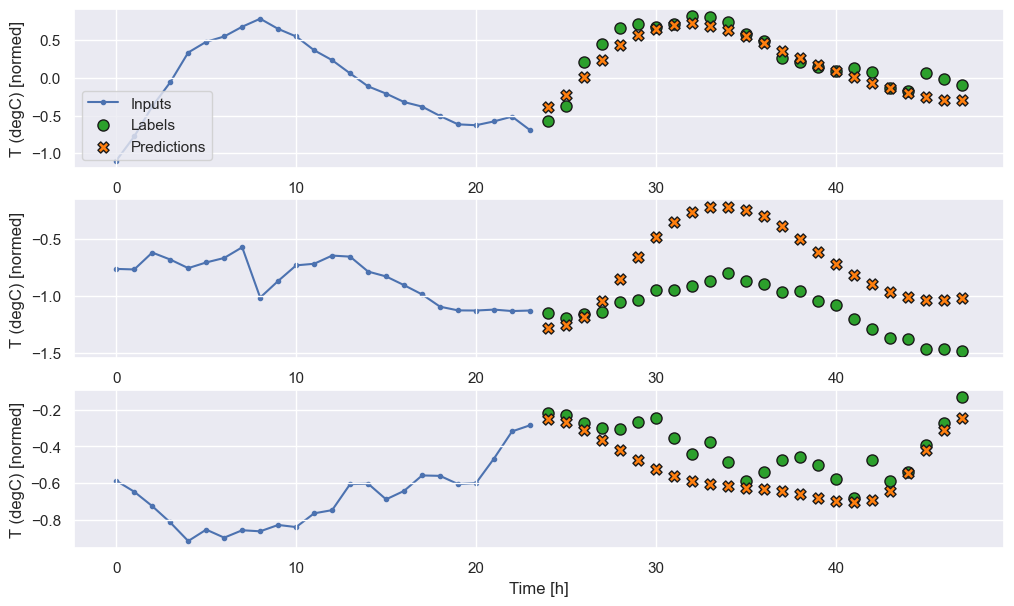

In [95]:
multi_window.plot(model=feedback_model, plot_col="T (degC)")

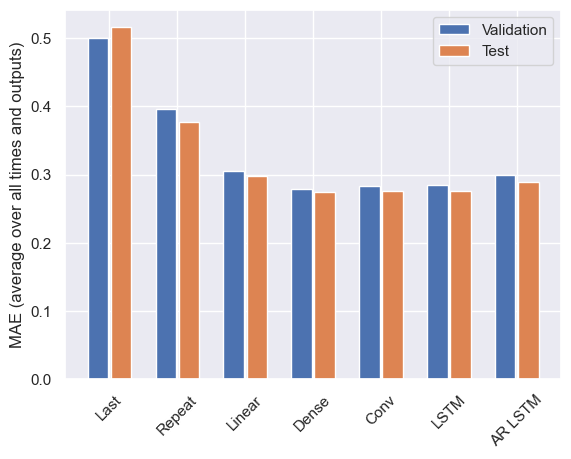

In [96]:
x = np.arange(len(multi_performance))
width = 0.3

metric_name = "mean_absolute_error"
val_mae = [v[metric_name] for v in multi_val_performance.values()]
test_mae = [v[metric_name] for v in multi_performance.values()]

plt.bar(x - 0.17, val_mae, width, label="Validation")
plt.bar(x + 0.17, test_mae, width, label="Test")
plt.xticks(ticks=x, labels=multi_performance.keys(),
           rotation=45)
plt.ylabel(f"MAE (average over all times and outputs)")
_ = plt.legend()


In [97]:
for name, value in multi_performance.items():
  print(f'{name:8s}: {value[metric_name]:0.4f}')


Last    : 0.5157
Repeat  : 0.3774
Linear  : 0.2978
Dense   : 0.2744
Conv    : 0.2758
LSTM    : 0.2766
AR LSTM : 0.2889
